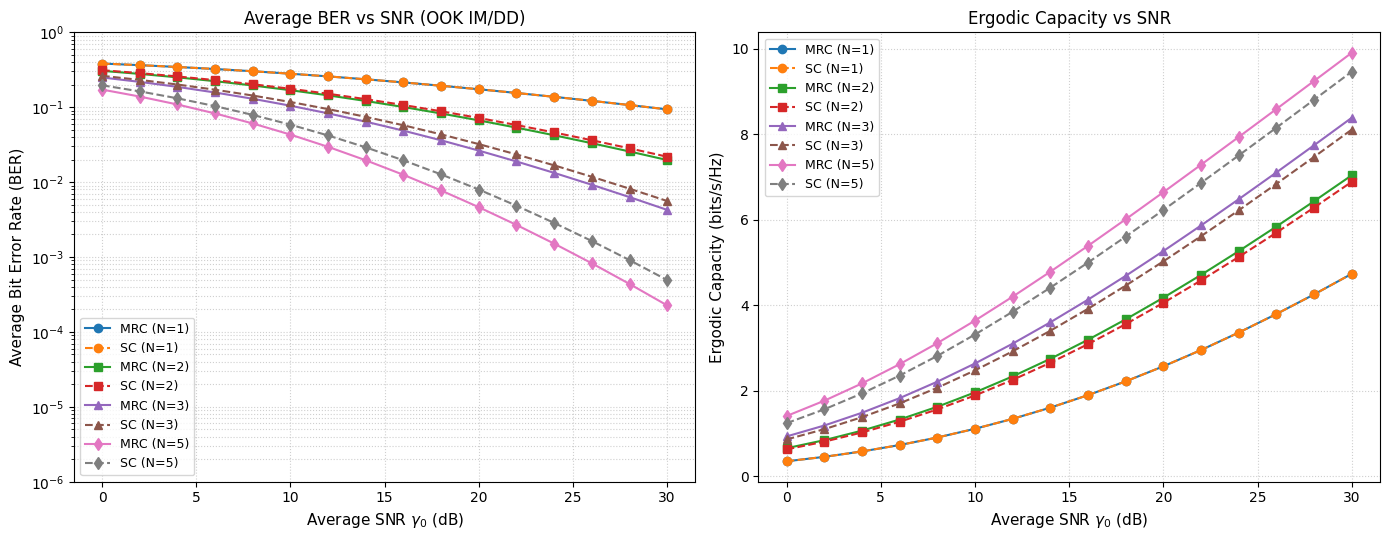

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc

omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}

for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

markers = ['o', 's', '^', 'd']
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

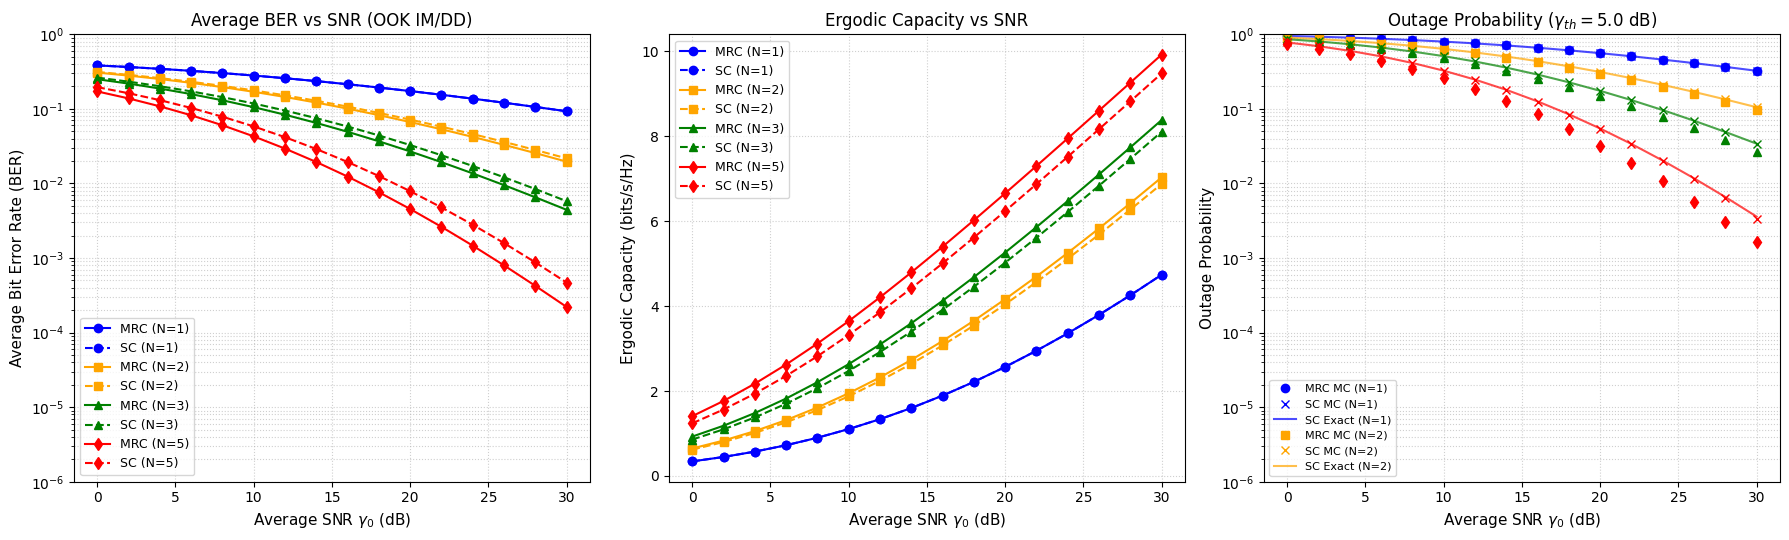

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# System parameters
omega = 0.4589
lam = 0.3449
a = 1.0421
b = 1.5768
c = 0.9424

A0 = 0.8532
rho = 0.8863

SNR_dB = np.linspace(0, 30, 16)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

gamma_th_dB = 5.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# ----------------- ANALYTICAL MEIJER G FUNCTIONS -----------------
def exact_sc_outage(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho, N):
    """Calculates Exact Outage Probability for SC using Meijer-G."""
    # First Meijer-G term parameters
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    # Second Meijer-G term parameters
    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    # Evaluate Meijer-G functions
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    F_gamma_single = term1 + term2
    return F_gamma_single ** N

# Dictionary to store theoretical SC outage
out_sc_exact = {N: [] for N in N_values}

def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

# Initialize dictionaries for storing Monte Carlo results
ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}

# Monte Carlo simulation loop
for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        # 1. Average BER
        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        # 2. Ergodic Capacity
        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        # 3. Outage Probability P(gamma < gamma_th)
        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))

        # 4. Exact Theoretical SC Outage
        out_sc_exact[N].append(exact_sc_outage(g0, gamma_th, omega, lam, a, b, c, A0, rho, N))

# ----------------- PLOTTING -----------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# Plot 1: BER
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# Plot 2: Ergodic Capacity
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

# Plot 3: Outage Probability
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]

    # Plot MC Simulations
    ax3.semilogy(SNR_dB, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')

    # Plot Exact Analytical SC
    ax3.semilogy(SNR_dB, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

ax3.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax3.set_ylabel('Outage Probability', fontsize=11)
ax3.set_title(f'Outage Probability ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=12)
ax3.set_ylim([1e-6, 1])
ax3.grid(True, which='both', linestyle=':', alpha=0.6)

# Simplified legend for Outage Plot to avoid clutter
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[:6], labels[:6], fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

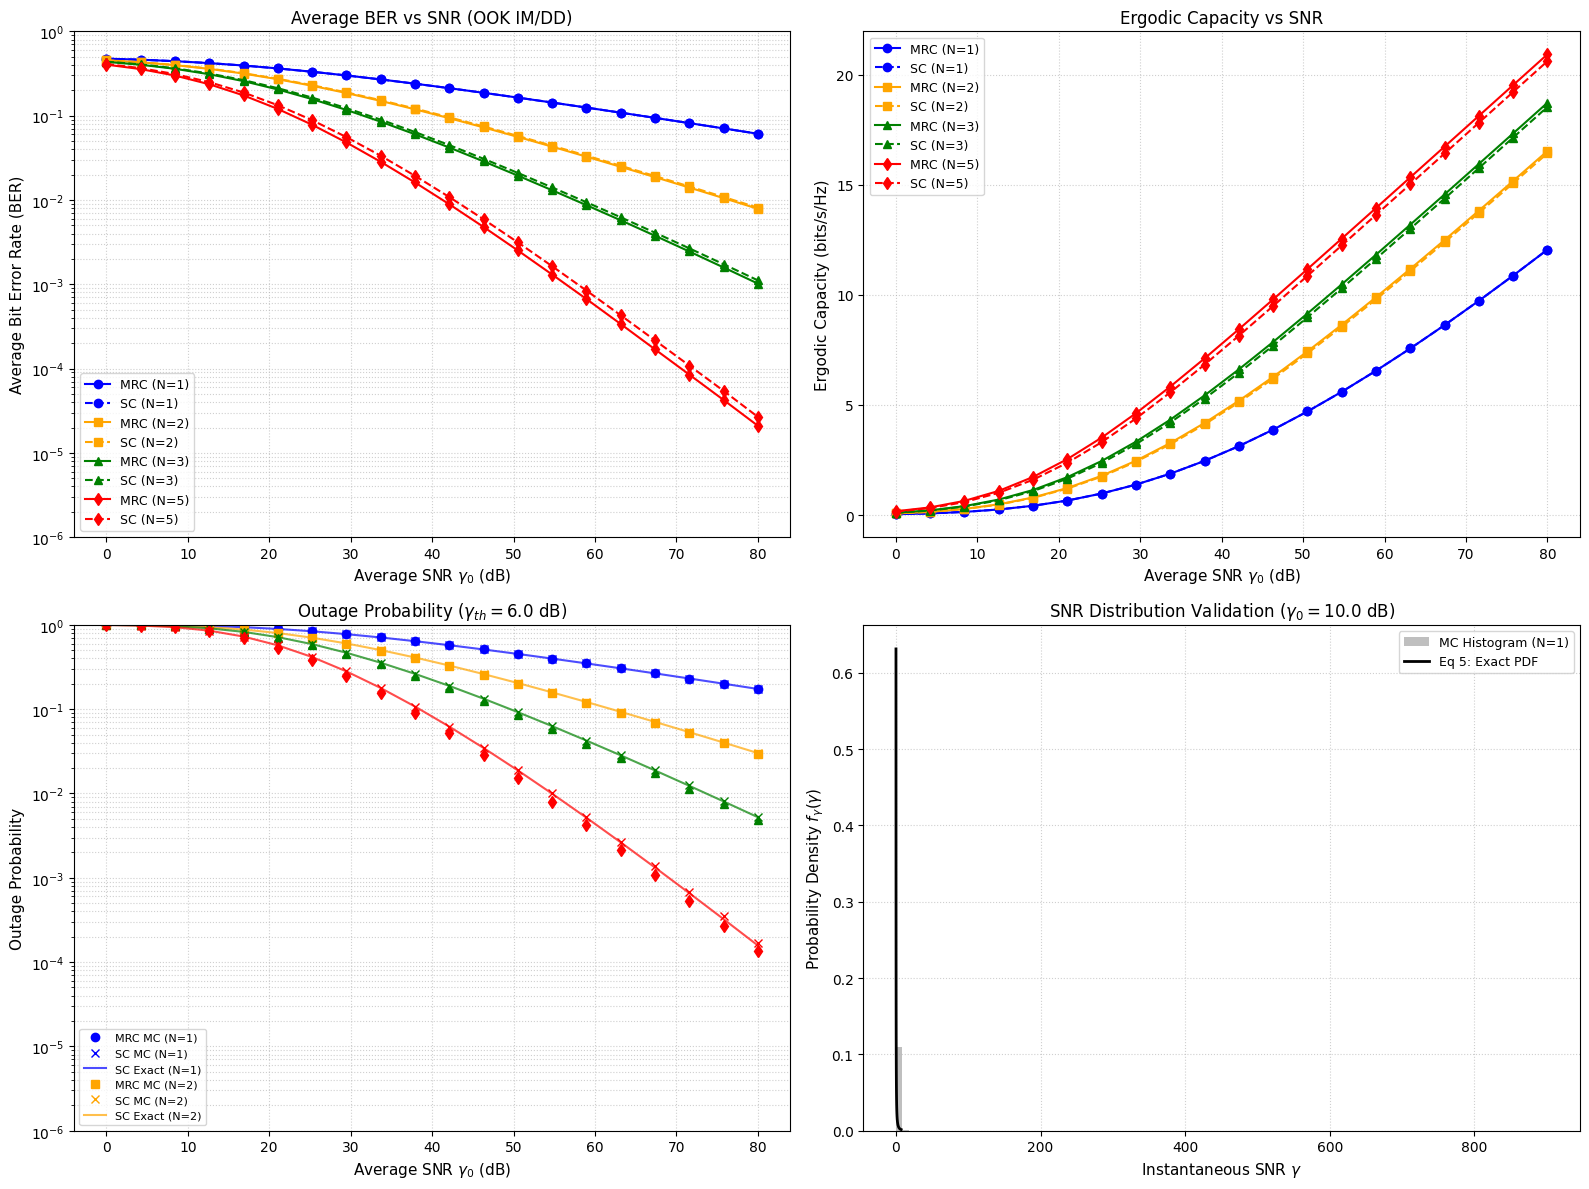

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# ==========================================
# PARAMETERS FROM TABLE I
# ==========================================

# 1. Pointing Error Parameters (Set 1)
A0 = 0.3900
rho = 0.5718

# 2. EGG Distribution Parameters (Set 1)
omega = 0.1770
lam = 0.4687
a = 0.6302
b = 1.1780
c = 0.8444

# 3. Threshold SNR
gamma_th_dB = 6.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# 4. Additional System Parameters
SNR_dB = np.linspace(0, 80, 20)
SNR_lin = 10.0 ** (SNR_dB / 10.0)
MC_SAMPLES = 1_000_000
N_values = [1, 2, 3, 5]

# ==========================================
# ANALYTICAL MEIJER G FUNCTIONS
# ==========================================
def exact_sc_outage(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho, N):
    """Calculates Exact Outage Probability for SC using Meijer-G."""
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    F_gamma_single = term1 + term2
    return F_gamma_single ** N

def eq5_pdf_snr(gamma, gamma_0, omega, lam, a, b, c, A0, rho):
    """Equation (5): Exact PDF of SNR for a single aperture."""
    if gamma <= 0:
        return 0.0

    a_s1 = [[], [rho**2 + 1]]
    b_s1 = [[1, rho**2], []]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma / gamma_0)
    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    term1 = (omega * rho**2 / (2.0 * gamma)) * G1

    a_s2 = [[], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], []]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma / gamma_0)**c)
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))
    term2 = ((1.0 - omega) * rho**2 / (2.0 * float(mpmath.gamma(a)) * gamma)) * G2

    return term1 + term2

# ==========================================
# MONTE CARLO SIMULATION
# ==========================================
def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

ber_mrc = {N: [] for N in N_values}
ber_sc  = {N: [] for N in N_values}
cap_mrc = {N: [] for N in N_values}
cap_sc  = {N: [] for N in N_values}
out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}
out_sc_exact = {N: [] for N in N_values}

# Store N=1 gains for PDF histogram validation
gains_n1 = None

for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    if N == 1:
        gains_n1 = gains[0].copy()

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        ber_mrc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_mrc) / np.sqrt(2.0))))
        ber_sc[N].append(np.mean(0.5 * erfc(np.sqrt(gamma_sc) / np.sqrt(2.0))))

        cap_mrc[N].append(np.mean(np.log2(1.0 + gamma_mrc)))
        cap_sc[N].append(np.mean(np.log2(1.0 + gamma_sc)))

        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))

        out_sc_exact[N].append(exact_sc_outage(g0, gamma_th, omega, lam, a, b, c, A0, rho, N))

# ==========================================
# PLOTTING
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axs.flatten()
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# Plot 1: BER
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax1.semilogy(SNR_dB, ber_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax1.semilogy(SNR_dB, ber_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax1.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax1.set_ylabel('Average Bit Error Rate (BER)', fontsize=11)
ax1.set_title('Average BER vs SNR (OOK IM/DD)', fontsize=12)
ax1.set_ylim([1e-6, 1])
ax1.grid(True, which='both', linestyle=':', alpha=0.6)
ax1.legend(fontsize=9)

# Plot 2: Ergodic Capacity
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax2.plot(SNR_dB, cap_mrc[N], marker=m, color=c_color, linestyle='-', label=f'MRC (N={N})')
    ax2.plot(SNR_dB, cap_sc[N], marker=m, color=c_color, linestyle='--', label=f'SC (N={N})')

ax2.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax2.set_ylabel('Ergodic Capacity (bits/s/Hz)', fontsize=11)
ax2.set_title('Ergodic Capacity vs SNR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=9)

# Plot 3: Outage Probability
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]
    ax3.semilogy(SNR_dB, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')
    ax3.semilogy(SNR_dB, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

ax3.set_xlabel('Average SNR $\\gamma_0$ (dB)', fontsize=11)
ax3.set_ylabel('Outage Probability', fontsize=11)
ax3.set_title(f'Outage Probability ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=12)
ax3.set_ylim([1e-6, 1])
ax3.grid(True, which='both', linestyle=':', alpha=0.6)
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[:6], labels[:6], fontsize=8, loc='lower left')

# Plot 4: Equation 5 Validation (PDF of SNR for N=1)
test_gamma_0_dB = 10.0
test_gamma_0_lin = 10.0 ** (test_gamma_0_dB / 10.0)
simulated_snr_n1 = test_gamma_0_lin * gains_n1

# Generate theoretical curve over a reasonable range
gamma_range = np.linspace(0.1, np.percentile(simulated_snr_n1, 99), 100)
pdf_theoretical = [eq5_pdf_snr(g, test_gamma_0_lin, omega, lam, a, b, c, A0, rho) for g in gamma_range]

ax4.hist(simulated_snr_n1, bins=100, density=True, alpha=0.5, color='gray', label='MC Histogram (N=1)')
ax4.plot(gamma_range, pdf_theoretical, 'k-', linewidth=2, label='Eq 5: Exact PDF')
ax4.set_xlabel('Instantaneous SNR $\\gamma$', fontsize=11)
ax4.set_ylabel('Probability Density $f_{\\gamma}(\\gamma)$', fontsize=11)
ax4.set_title(f'SNR Distribution Validation ($\\gamma_0 = {test_gamma_0_dB}$ dB)', fontsize=12)
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()

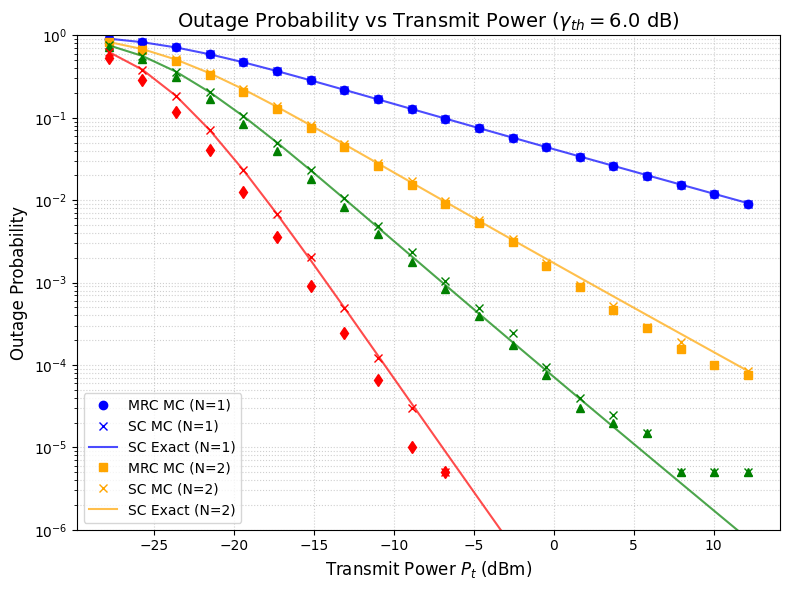

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import mpmath

# Ensure mpmath evaluates as standard floats for plotting compatibility
mpmath.mp.dps = 15

# ==========================================
# PARAMETERS FROM TABLE I
# ==========================================

# 1. Pointing Error Parameters (Set 1)
A0 = 1
rho = 8

# 2. EGG Distribution Parameters (Set 1)
omega = 0.1770
lam = 0.4687
a = 0.6302
b = 1.1780
c = 0.8444

# 3. Link & Noise Parameters (For Transmit Power Conversion)
sigma_w2 = 1e-14
d = 50.0
alpha = 0.056
h_d = np.exp(-alpha * d)

# 4. Threshold SNR
gamma_th_dB = 6.0
gamma_th = 10.0 ** (gamma_th_dB / 10.0)

# 5. Additional System Parameters (Expanded range to capture the deep fading)
SNR_dB = np.linspace(0, 80, 20)
SNR_lin = 10.0 ** (SNR_dB / 10.0)

# Calculate Transmit Power in Watts, then convert to dBm
Pt_W = np.sqrt(SNR_lin * sigma_w2) / h_d
Pt_dBm = 10.0 * np.log10(Pt_W / 1e-3)

MC_SAMPLES = 200_000
N_values = [1, 2, 3, 5]

# ==========================================
# ANALYTICAL MEIJER G FUNCTIONS
# ==========================================
def exact_sc_outage(SNR_lin_val, gamma_th_val, omega, lam, a, b, c, A0, rho, N):
    a_s1 = [[1], [rho**2 + 1]]
    b_s1 = [[1, rho**2], [0]]
    z1 = (1.0 / (lam * A0)) * np.sqrt(gamma_th_val / SNR_lin_val)

    a_s2 = [[1], [(rho**2)/c + 1]]
    b_s2 = [[a, (rho**2)/c], [0]]
    z2 = (1.0 / ((b**c) * (A0**c))) * (np.sqrt(gamma_th_val / SNR_lin_val)**c)

    G1 = float(mpmath.meijerg(a_s1, b_s1, z1))
    G2 = float(mpmath.meijerg(a_s2, b_s2, z2))

    term1 = omega * (rho**2) * G1
    term2 = ((1.0 - omega) * (rho**2) / (c * float(mpmath.gamma(a)))) * G2

    F_gamma_single = term1 + term2
    return F_gamma_single ** N

# ==========================================
# MONTE CARLO SIMULATION
# ==========================================
def generate_channel_gain_sq(num_samples):
    is_exp = np.random.rand(num_samples) < omega
    h_exp = np.random.exponential(scale=lam, size=num_samples)
    y_gamma = np.random.gamma(shape=a, scale=1.0, size=num_samples)
    h_gg = b * (y_gamma ** (1.0 / c))
    h_t = np.where(is_exp, h_exp, h_gg)

    u = np.random.uniform(0.0, 1.0, size=num_samples)
    h_p = A0 * (u ** (1.0 / (rho ** 2)))

    return (h_t * h_p) ** 2

out_mrc = {N: [] for N in N_values}
out_sc  = {N: [] for N in N_values}
out_sc_exact = {N: [] for N in N_values}

for N in N_values:
    gains = np.zeros((N, MC_SAMPLES))
    for i in range(N):
        gains[i] = generate_channel_gain_sq(MC_SAMPLES)

    gain_mrc = np.sum(gains, axis=0)
    gain_sc = np.max(gains, axis=0)

    for g0 in SNR_lin:
        gamma_mrc = g0 * gain_mrc
        gamma_sc = g0 * gain_sc

        out_mrc[N].append(np.mean(gamma_mrc < gamma_th))
        out_sc[N].append(np.mean(gamma_sc < gamma_th))
        out_sc_exact[N].append(exact_sc_outage(g0, gamma_th, omega, lam, a, b, c, A0, rho, N))

# ==========================================
# PLOTTING
# ==========================================
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))
markers = ['o', 's', '^', 'd']
colors = ['blue', 'orange', 'green', 'red']

# Plot Outage Probability vs Transmit Power
for idx, N in enumerate(N_values):
    m = markers[idx % len(markers)]
    c_color = colors[idx % len(colors)]

    # Plot MC Simulations
    ax3.semilogy(Pt_dBm, out_mrc[N], marker=m, color=c_color, linestyle='None', label=f'MRC MC (N={N})')
    ax3.semilogy(Pt_dBm, out_sc[N], marker='x', color=c_color, linestyle='None', label=f'SC MC (N={N})')

    # Plot Exact Analytical SC
    ax3.semilogy(Pt_dBm, out_sc_exact[N], color=c_color, linestyle='-', alpha=0.7, label=f'SC Exact (N={N})')

ax3.set_xlabel('Transmit Power $P_t$ (dBm)', fontsize=12)
ax3.set_ylabel('Outage Probability', fontsize=12)
ax3.set_title(f'Outage Probability vs Transmit Power ($\\gamma_{{th}} = {gamma_th_dB}$ dB)', fontsize=14)
ax3.set_ylim([1e-6, 1])
ax3.grid(True, which='both', linestyle=':', alpha=0.6)

# Organize legend
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[:6], labels[:6], fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()

MRC AND RC PLOT

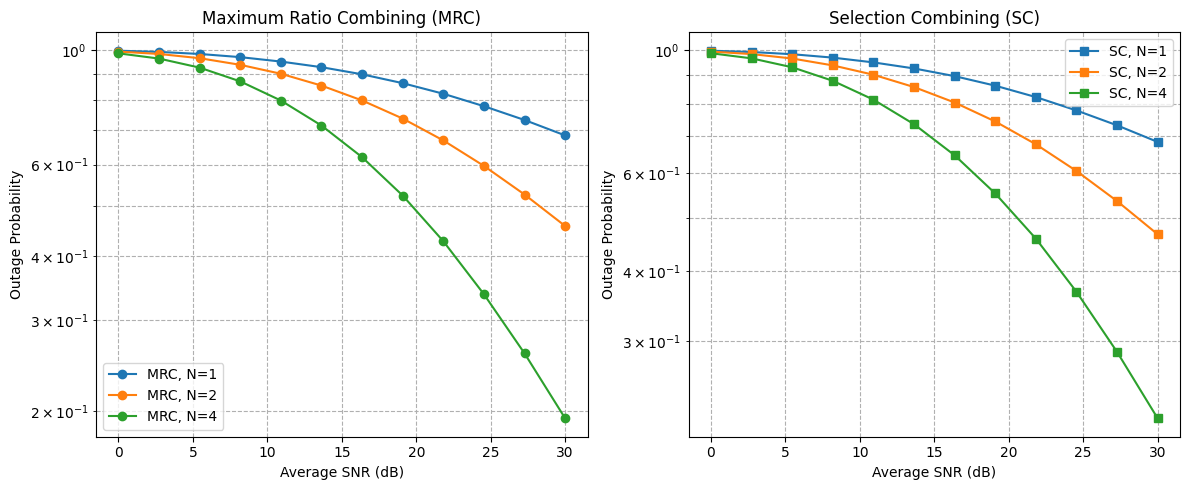

In [ ]:
# ----------------- PLOTTING -----------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MRC Outage Probability
for N in N_values:
    ax1.semilogy(SNR_dB, out_mrc_sim[N], marker='o', label=f'MRC, N={N}')

ax1.set_title('Maximum Ratio Combining (MRC)')
ax1.set_xlabel('Average SNR (dB)')
ax1.set_ylabel('Outage Probability')
ax1.grid(True, which="both", ls="--")
ax1.legend()

# Plot SC Outage Probability
for N in N_values:
    ax2.semilogy(SNR_dB, out_sc_sim[N], marker='s', label=f'SC, N={N}')

ax2.set_title('Selection Combining (SC)')
ax2.set_xlabel('Average SNR (dB)')
ax2.set_ylabel('Outage Probability')
ax2.grid(True, which="both", ls="--")
ax2.legend()

plt.tight_layout()
plt.show()